# Measuring the AI Learning Content Coverage Gap
## A Case Study of Anthropic Academy

*Research notebook · Data collected 2026-05-20 · [Craftmindship analysis](https://craftmindship.com/analysis/anthropic-academy-skill-formation)*

## 60-Second Summary

**Dataset:** 329 Anthropic product release entries (225 substantive, 104 maintenance) from Claude release notes and Claude Code changelog, plus 18 Anthropic Academy courses from the public Skilljar catalog.

**Observed period:** April 2025 to May 2026

**Key constraint:** No public course update timestamps were visible on any learning platform examined (Anthropic Academy, OpenAI Academy, Google AI). This notebook uses **topic-level coverage gap** as the metric, not update lag.

**Headline findings:**

1. Anthropic shipped 225 substantive releases over the observed period — 193 from Claude Code alone.
2. Claude Code is a high-velocity surface: 292 changelog entries across 12 topic subcategories.
3. Of 12 topic areas, 3 are visibly covered by dedicated Academy courses, 1 partially covered, and 8 have no visible coverage.
4. The highest-pressure uncovered topics are **permissions/security** (21 substantive releases) and **IDE integration** (14 substantive releases).

**Limitation:** This is a single-vendor case study of Anthropic. It is not a cross-vendor benchmark. OpenAI and Google data sources were attempted in reconnaissance but encountered access restrictions or quality issues.

## Why This Notebook Exists

AI products ship faster than course catalogs can track. But "faster" is a feeling — this notebook puts numbers on it.

The goal is narrow: measure what is publicly visible about the gap between Anthropic's product release velocity and Anthropic Academy's public course coverage, using only publicly available data.

This is the evidence layer for the Craftmindship article [*Anthropic Academy and the Skill Formation Gap*](https://craftmindship.com/analysis/anthropic-academy-skill-formation).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

PROCESSED = Path('../data/processed')
CHARTS = Path('../outputs/charts')
CHARTS.mkdir(parents=True, exist_ok=True)

# Chart style
COLORS = {
    "Claude": "#D97706", "Claude Code": "#2563EB",
    "substantive": "#2563EB", "maintenance": "#94A3B8",
    "covered": "#16A34A", "partial": "#EAB308", "not visible": "#DC2626",
}

def style_ax(ax, title, xlabel, ylabel, note=None):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if note:
        ax.annotate(note, xy=(0, -0.15), xycoords="axes fraction",
                    fontsize=7, color="#6B7280", style="italic")

## Data Sources and Feasibility Recap

    Data collected 2026-05-20. A prior reconnaissance phase ([00_data_reconnaissance.ipynb](00_data_reconnaissance.ipynb)) assessed all sources.

    | Source | Vendor | Type | Status | HTTP |
|--------|--------|------|--------|------|
| anthropic_release_notes | Anthropic | product_release | success | 200 |
| claude_code_changelog | Anthropic | product_release | success | 200 |
| google_gemini_changelog | Google | product_release | success | 200 |
| openai_changelog | OpenAI | product_release | forbidden | 403 |
| openai_index | OpenAI | product_release | forbidden | 403 |
| anthropic_academy | Anthropic | learning_content | success | 200 |
| openai_academy | OpenAI | learning_content | success | 200 |
| google_ai_tutorials | Google | learning_content | success | 200 |

    **Key decisions:**
    - **Anthropic (primary):** Clean release data + clean course catalog → included in V1
    - **OpenAI (excluded):** Changelog and index return HTTP 403
    - **Google (excluded from V1):** Release data is clean, learning content source needs manual curation

## Why the Metric Is Coverage Gap, Not Update Lag

The natural metric would be: *days from product release to course update*. This requires two timestamps:
1. Product release date (available)
2. Course update date (**not available**)

**No learning platform examined exposes course update timestamps publicly.**

| Platform | Update date visible? |
|----------|---------------------|
| Anthropic Academy (Skilljar) | No |
| OpenAI Academy | No |
| Google AI Dev | No |

The defensible alternative: **topic-level coverage gap as of the collection date.**

In [2]:
# Load processed datasets
releases = pd.read_csv(PROCESSED / 'anthropic_product_releases.csv')
releases['release_date'] = pd.to_datetime(releases['release_date'])
releases['release_month'] = releases['release_date'].dt.to_period('M')

courses = pd.read_csv(PROCESSED / 'anthropic_learning_content.csv')
gap_summary = pd.read_csv(PROCESSED / 'coverage_gap_summary.csv')
mapping = pd.read_csv(PROCESSED / 'topic_coverage_mapping_reviewed.csv')

print(f"Releases: {len(releases)} ({(releases['release_substance']=='substantive').sum()} substantive, "
      f"{(releases['release_substance']=='maintenance').sum()} maintenance)")
print(f"Academy courses: {len(courses)}")
print(f"Date range: {releases['release_date'].min().date()} to {releases['release_date'].max().date()}")

Releases: 329 (225 substantive, 104 maintenance)
Academy courses: 18
Date range: 2025-04-02 to 2026-05-19


## Anthropic Product Release Velocity

### Overall monthly velocity

In [3]:
# Release counts by product area
area_summary = releases.groupby('product_area').agg(
    total=('title', 'size'),
    substantive=('release_substance', lambda x: (x == 'substantive').sum()),
    maintenance=('release_substance', lambda x: (x == 'maintenance').sum()),
)
area_summary

,total,substantive,maintenance
product_area,,,
Claude,37,32,5
Claude Code,292,193,99


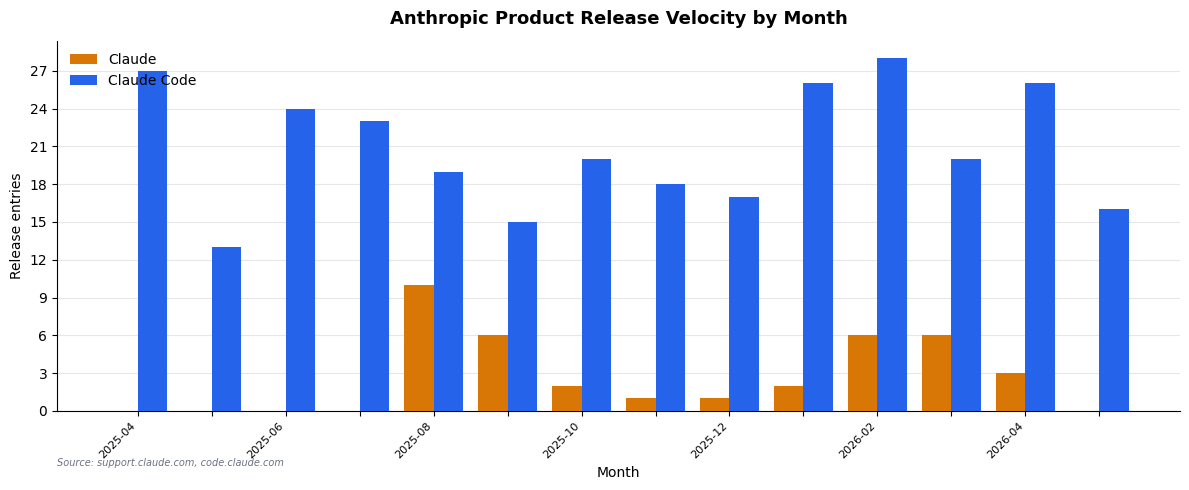

In [4]:
# Chart 1: Monthly release velocity by product area
monthly = releases.groupby(['release_month', 'product_area']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(monthly))
w = 0.4
ax.bar([i - w/2 for i in x], monthly.get('Claude', 0).values, w,
       label='Claude', color=COLORS['Claude'], zorder=3)
ax.bar([i + w/2 for i in x], monthly.get('Claude Code', 0).values, w,
       label='Claude Code', color=COLORS['Claude Code'], zorder=3)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=8)
for i, lb in enumerate(ax.get_xticklabels()):
    if i % 2 != 0: lb.set_visible(False)
ax.legend(loc='upper left', frameon=False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3, zorder=0)
style_ax(ax, 'Anthropic Product Release Velocity by Month', 'Month', 'Release entries',
         'Source: support.claude.com, code.claude.com')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_velocity_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### Substantive vs maintenance split

Not all releases create learning-content decay pressure. Bug fixes and docs-only patches do not require course updates.

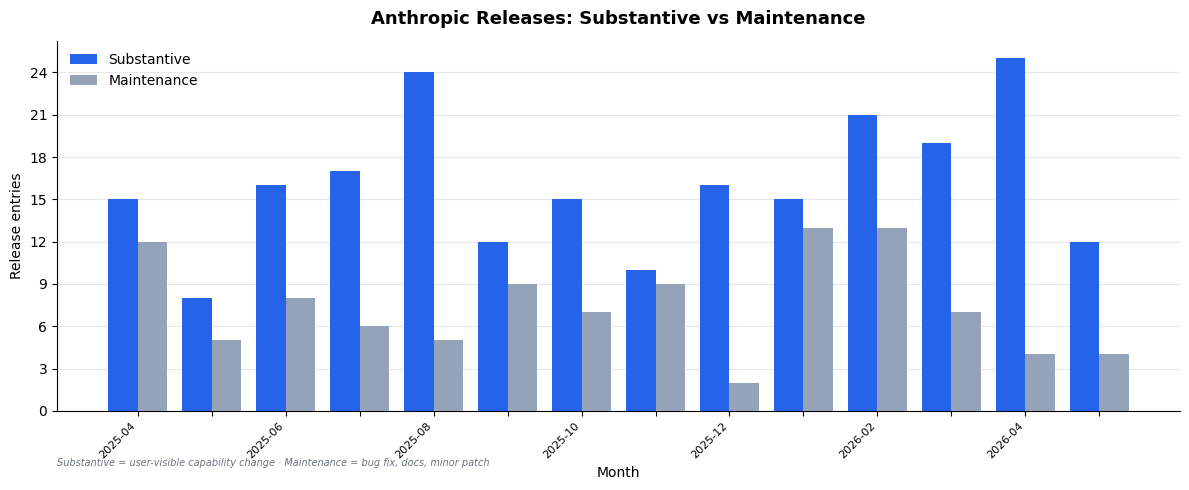

In [5]:
# Chart 2: Monthly velocity by substance
releases['substance_label'] = releases['release_substance'].map(
    {'substantive': 'Substantive', 'maintenance': 'Maintenance'})
monthly_s = releases.groupby(['release_month', 'substance_label']).size().unstack(fill_value=0)
monthly_s.index = monthly_s.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(monthly_s))
w = 0.4
ax.bar([i - w/2 for i in x], monthly_s.get('Substantive', 0).values, w,
       label='Substantive', color=COLORS['substantive'], zorder=3)
ax.bar([i + w/2 for i in x], monthly_s.get('Maintenance', 0).values, w,
       label='Maintenance', color=COLORS['maintenance'], zorder=3)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_s.index, rotation=45, ha='right', fontsize=8)
for i, lb in enumerate(ax.get_xticklabels()):
    if i % 2 != 0: lb.set_visible(False)
ax.legend(loc='upper left', frameon=False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3, zorder=0)
style_ax(ax, 'Anthropic Releases: Substantive vs Maintenance', 'Month', 'Release entries',
         'Substantive = user-visible capability change · Maintenance = bug fix, docs, minor patch')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_velocity_substance.png', dpi=150, bbox_inches='tight')
plt.show()

**225** of 329 releases (68%) are classified as substantive — meaning they introduce a user-visible capability or behavior change.

Classification rule: "substantive" if it adds a new feature, changes API behavior, introduces a new model, modifies permissions, or deprecates functionality. Bug fixes, doc updates, and minor patches are "maintenance." Entries where fix-related signals dominate the description are classified as maintenance even if topic keywords are present.

## Release Topic Mix

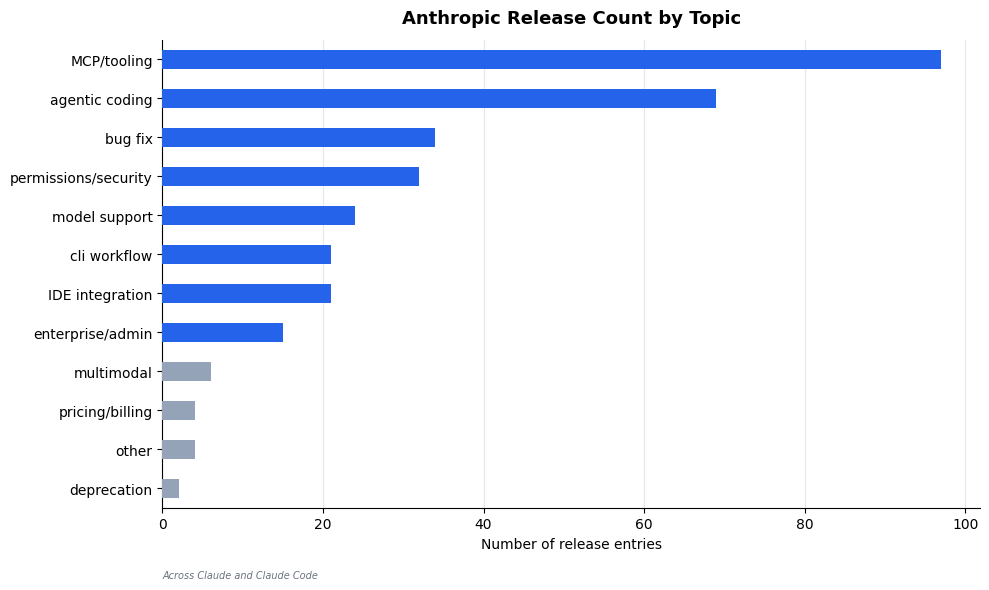

In [6]:
# Chart 3: Release count by topic
tc = releases.groupby('topic_subcategory').size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563EB' if tc[t] > 10 else '#94A3B8' for t in tc.index]
tc.plot(kind='barh', ax=ax, color=colors, zorder=3)
ax.grid(axis='x', alpha=0.3, zorder=0)
style_ax(ax, 'Anthropic Release Count by Topic', 'Number of release entries', '',
         'Across Claude and Claude Code')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_topics.png', dpi=150, bbox_inches='tight')
plt.show()

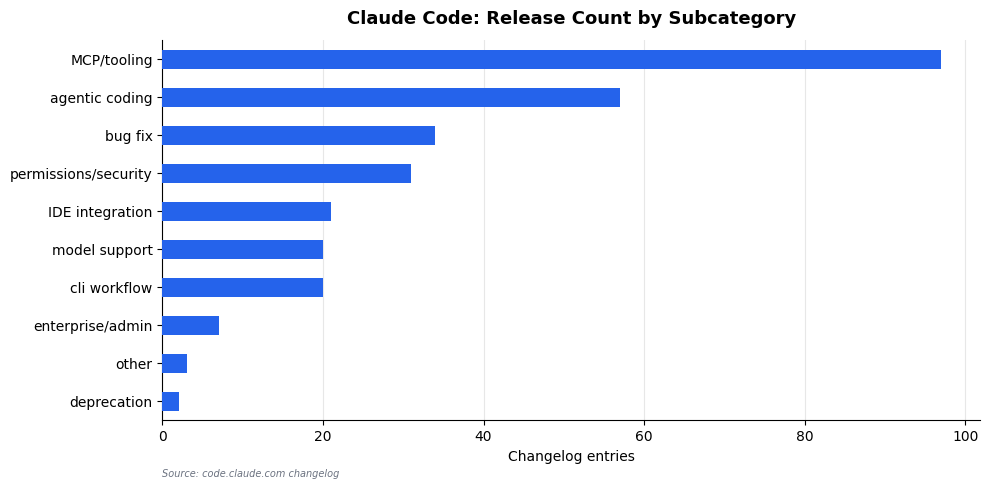

In [7]:
# Chart 4: Claude Code subcategories
cc = releases[releases['product_area'] == 'Claude Code']
sc = cc.groupby('topic_subcategory').size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
sc.plot(kind='barh', ax=ax, color='#2563EB', zorder=3)
ax.grid(axis='x', alpha=0.3, zorder=0)
style_ax(ax, 'Claude Code: Release Count by Subcategory', 'Changelog entries', '',
         'Source: code.claude.com changelog')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_claude_code_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()

## Anthropic Academy Course Catalog

    Anthropic Academy lists **18 public courses** on its Skilljar catalog. No course update timestamps are publicly visible.

    | # | Course | Description | Assigned Topics |
|---|--------|-------------|-----------------|
| 1 | Claude 101 | Learn how to use Claude for everyday work tasks, understand core features, and explore resources for more advanced learn | model support |
| 2 | Claude Code 101 | Learn how to use Claude Code effectively in your daily development workflow. | cli workflow, model support |
| 3 | Introduction to Claude Cowork | Learn to work alongside Claude on your real files and projects. This hands-on course covers the Cowork task loop, plugin | MCP/tooling, agentic coding, model support |
| 4 | Claude Code in Action | Integrate Claude Code into your development workflow | cli workflow, model support |
| 5 | AI Fluency: Framework & Foundations | Learn to collaborate with AI systems effectively, efficiently, ethically, and safely | — |
| 6 | Building with the Claude API | This comprehensive course covers the full spectrum of working with Anthropic models using the Claude API | model support |
| 7 | Introduction to Model Context Protocol | Learn to build Model Context Protocol servers and clients from scratch using Python. Master MCP's three core primitives— | MCP/tooling, cli workflow, model support |
| 8 | AI Fluency for educators | This course empowers faculty, instructional designers, and educational leaders to apply AI Fluency into their own teachi | — |
| 9 | AI Fluency for students | This course empowers students to develop AI Fluency skills that enhance learning, career planning, and academic success  | — |
| 10 | Model Context Protocol: Advanced Topics | Discover advanced Model Context Protocol implementation patterns including sampling, notifications, file system access,  | MCP/tooling, model support |
| 11 | Claude with Amazon Bedrock | As part of an accreditation program created for AWS, Anthropic launched a first-of-its-kind training for AWS employees.  | model support |
| 12 | Claude with Google Cloud's Vertex AI | This comprehensive course covers the full spectrum of working with Anthropic models through Google Cloud's Vertex AI. | model support |
| 13 | Teaching AI Fluency | This course empowers academic faculty, instructional designers, and others to teach and assess AI Fluency in instructor- | — |
| 14 | AI Fluency for nonprofits | This course empowers nonprofit professionals to develop AI fluency in order to increase organizational impact and effici | — |
| 15 | Introduction to agent skills | Learn how to build, configure, and share Skills in Claude Code — reusable markdown instructions that Claude automaticall | agentic coding, cli workflow, model support |
| 16 | Introduction to subagents | Learn how to use and create sub-agents in Claude Code to manage context, delegate tasks, and build specialized   workflo | agentic coding, cli workflow, model support |
| 17 | AI Capabilities and Limitations | An introductory course about how AI works | — |
| 18 | AI Fluency for Small Businesses | This course empowers small businesses to develop AI fluency in order to increase organizational impact and efficiency wh | — |

In [8]:
# Full course catalog with first 150 chars of description
course_display = courses[['title', 'description', 'url', 'topic_category']].copy()
course_display['description'] = course_display['description'].str[:150]
course_display

,title,description,url,topic_category
0,Claude 101,Learn how to use Claude for everyday work task...,https://anthropic.skilljar.com/claude-101,docs/tutorial
1,Claude Code 101,Learn how to use Claude Code effectively in yo...,https://anthropic.skilljar.com/claude-code-101,coding
2,Introduction to Claude Cowork,Learn to work alongside Claude on your real fi...,https://anthropic.skilljar.com/introduction-to...,agent/tooling
3,Claude Code in Action,Integrate Claude Code into your development wo...,https://anthropic.skilljar.com/claude-code-in-...,coding
4,AI Fluency: Framework & Foundations,Learn to collaborate with AI systems effective...,https://anthropic.skilljar.com/ai-fluency-fram...,docs/tutorial
5,Building with the Claude API,This comprehensive course covers the full spec...,https://anthropic.skilljar.com/claude-with-the...,model release
6,Introduction to Model Context Protocol,Learn to build Model Context Protocol servers ...,https://anthropic.skilljar.com/introduction-to...,agent/tooling
7,AI Fluency for educators,"This course empowers faculty, instructional de...",https://anthropic.skilljar.com/ai-fluency-for-...,other
8,AI Fluency for students,This course empowers students to develop AI Fl...,https://anthropic.skilljar.com/ai-fluency-for-...,agent/tooling
9,Model Context Protocol: Advanced Topics,Discover advanced Model Context Protocol imple...,https://anthropic.skilljar.com/model-context-p...,agent/tooling


## Topic-to-Course Coverage Mapping

Each topic was matched against Academy courses using strict rules:
- **Covered:** Course title or description explicitly mentions the topic or feature name.
- **Partial:** Thematic overlap exists but no dedicated course for the topic.
- **Not visible:** No course title or description visibly mentions the topic.

Only public text from course titles and descriptions was used. Matching evidence is in `data/processed/topic_coverage_mapping_reviewed.csv`.

In [9]:
# Coverage mapping summary
mapping_display = mapping[['topic_subcategory', 'release_count', 'substantive_release_count',
                            'coverage_status', 'coverage_confidence', 'related_academy_courses',
                            'needs_human_review']].copy()
mapping_display['related_academy_courses'] = mapping_display['related_academy_courses'].fillna('').str[:60]
mapping_display.sort_values('substantive_release_count', ascending=False)

,topic_subcategory,release_count,substantive_release_count,coverage_status,coverage_confidence,related_academy_courses,needs_human_review
1,MCP/tooling,97,85,covered,high,Introduction to Claude Cowork; Introduction to...,False
2,agentic coding,69,54,covered,high,Introduction to Claude Cowork; Introduction to...,False
10,permissions/security,32,21,not visible,high,,False
7,model support,24,16,partial,medium,Claude 101; Claude Code 101; Introduction to C...,True
0,IDE integration,21,14,not visible,high,,False
6,enterprise/admin,15,14,not visible,high,,False
4,cli workflow,21,13,covered,high,Claude Code 101; Claude Code in Action,False
8,multimodal,6,3,not visible,high,,False
11,pricing/billing,4,3,not visible,high,,False
5,deprecation,2,2,not visible,high,,False


## Coverage Gap Findings

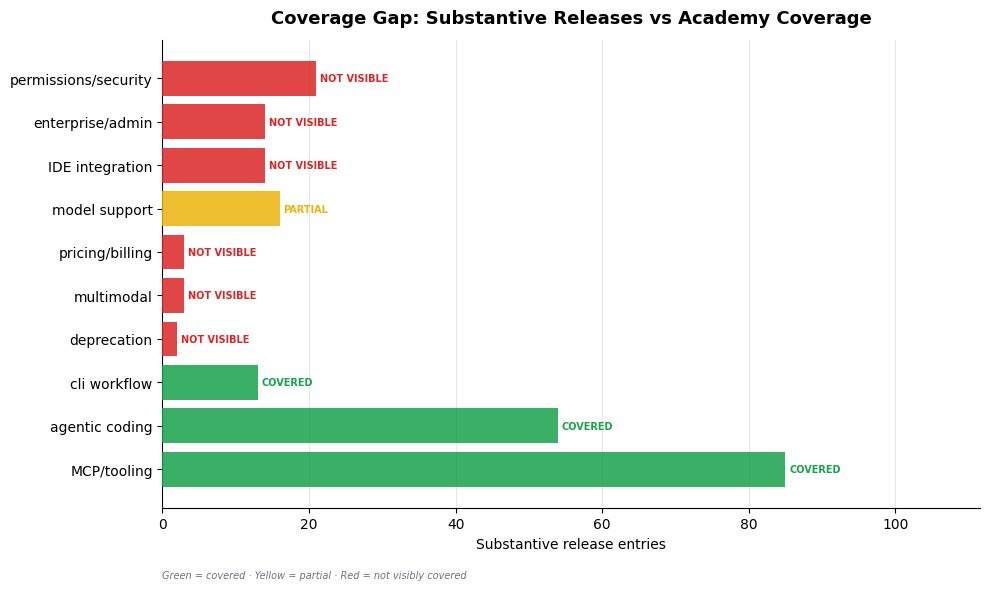

In [10]:
# Chart 5: Coverage gap by topic
df = gap_summary.copy()
df['gap_score_num'] = pd.to_numeric(df['gap_score'], errors='coerce').fillna(0)
df = df[df['substantive_releases'] > 0].sort_values('gap_score_num', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [COLORS.get(s, '#94A3B8') for s in df['coverage_status']]
ax.barh(df['topic_subcategory'], df['substantive_releases'], color=bar_colors, zorder=3, alpha=0.85)
for i, (_, row) in enumerate(df.iterrows()):
    status = row['coverage_status']
    color = COLORS.get(status, '#6B7280')
    ax.text(row['substantive_releases'] + 0.5, i, status.upper(),
            va='center', fontsize=7, color=color, fontweight='bold')
ax.grid(axis='x', alpha=0.3, zorder=0)
style_ax(ax, 'Coverage Gap: Substantive Releases vs Academy Coverage',
         'Substantive release entries', '',
         'Green = covered · Yellow = partial · Red = not visibly covered')
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_coverage_gap_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Gap score calculation: not visible = substantive_releases, partial = half, covered = 0
gap_display = gap_summary[['topic_subcategory', 'total_releases', 'substantive_releases',
                            'breaking_changes', 'courses_covering_count',
                            'coverage_status', 'gap_score']].copy()
gap_display = gap_display.sort_values('gap_score', ascending=False,
                                      key=lambda x: pd.to_numeric(x, errors='coerce').fillna(-1))
gap_display

,topic_subcategory,total_releases,substantive_releases,breaking_changes,courses_covering_count,coverage_status,gap_score
0,permissions/security,32,21,0,0,not visible,21
1,IDE integration,21,14,0,0,not visible,14
2,enterprise/admin,15,14,0,0,not visible,14
3,model support,24,16,0,11,partial,8
4,multimodal,6,3,0,0,not visible,3
5,pricing/billing,4,3,0,0,not visible,3
6,deprecation,2,2,2,0,not visible,2
7,MCP/tooling,97,85,0,3,covered,0
8,agentic coding,69,54,0,3,covered,0
9,bug fix,34,0,1,0,not visible,0


### Key observations

1. **MCP/tooling** (85 substantive releases) and **agentic coding** (54) are the highest-velocity areas and are **covered** by dedicated courses.

2. **Permissions/security** (21 substantive releases) is the largest **uncovered** topic — no Academy course visibly addresses permissions, security, or access control in Claude Code.

3. **IDE integration** (14 substantive releases) and **enterprise/admin** (14) are also uncovered.

4. **Model support** (16 substantive releases) is **partially** covered — "Building with the Claude API" mentions models but no course is dedicated to model selection or capabilities.

5. Bug fix and other maintenance topics correctly show gap_score = 0.

## What This Proves and Does Not Prove

| This notebook supports | This notebook does NOT support |
|----------------------|-------------------------------|
| Anthropic public product surfaces changed frequently over the observed period | Any claim about Anthropic's internal education efforts |
| Claude Code creates a high-velocity learning surface | Any claim that Anthropic Academy is "bad" or "neglected" |
| Some fast-moving topics are not visibly covered in the public Academy catalog | Any claim about course quality or depth |
| Course update timestamps are not publicly visible | Exact content decay days or update lag |
| Topic-level coverage gap is a defensible V1 metric | Any comparative claim across AI vendors |
| The release velocity should be interpreted carefully (substantive vs maintenance) | Any claim about internal automation or investment |

## Implications for Living Learning Infrastructure

If the coverage gap pattern holds — and this V1 can only measure one vendor's public surface — it suggests:

1. **Release velocity outpaces static catalogs.** Even with 18 courses, fast-moving technical subcategories (permissions, IDE, enterprise admin) are not visibly covered.
2. **The substance split matters.** Raw release counts overstate the learning load. Filtering to substantive releases gives a more honest picture.
3. **Coverage ≠ currency.** Without update timestamps, we cannot distinguish "covered and current" from "covered but stale."
4. **Living learning infrastructure** — continuously updated content tied to release pipelines — may be more appropriate than periodic course releases for high-velocity product surfaces.

These are directional observations from a single vendor's public surface, not general conclusions about AI education infrastructure.

## Limitations

1. **Single vendor.** Anthropic-only case study. OpenAI and Google excluded due to source access/quality issues.
2. **No course update timestamps.** Metric is coverage gap, not update lag.
3. **Title/description matching only.** Courses may cover topics not in their visible public text.
4. **Keyword-based topic classification.** Substance audit showed ~7% false-positive rate (substantive entries that should be maintenance).
5. **Claude Code changelog volume.** Each entry may represent varying levels of user-facing change.
6. **No enrollment or completion data.** We measure catalog presence, not learning effectiveness.
7. **Snapshot in time.** Data collected 2026-05-20.

## Next Research Steps

1. **Multi-vendor comparison.** Retry OpenAI with Playwright or manual methods.
2. **Sub-item categorization.** Classify Claude Code at the bullet-point level.
3. **Temporal tracking.** Re-run periodically to detect catalog changes.
4. **Course content depth.** Enrolled-user assessment of whether content covers specific features.
5. **Community learning proxy.** Stack Overflow, GitHub Discussions, or Discord as informal coverage signals.

---

*Notebook generated 2026-05-20 · Source: [github.com/.../ai-content-decay-analysis](https://github.com/)*